In [1]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [8]:
os.getuid()

1000

In [10]:
DECAY_RATE = 1

start_datetime_str = "2024-10-31 13-46-21"
end_datetime_str = "2024-11-04 08-00-00"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False)

df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,Linear Velocity [m/s],Angular Velocity [rad/s],Image pixel 0,Image pixel 1,...,Image pixel 1190,Image pixel 1191,Image pixel 1192,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199
0,0.000,0.489796,None,0.489796,1,1,0.475357,0.728461,0.450980,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000,0.163265,None,0.653061,1,1,0.299329,-1.080101,0.450980,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.198,0.040816,None,0.693878,1,1,0.077997,-1.387617,0.380392,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.363,0.122449,None,0.816327,1,1,0.433088,0.317501,0.454902,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.528,0.000000,None,0.816327,1,1,0.354036,-1.505365,0.294118,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
exp_config = load_exp_config(df.experiment_path.values[0])

exp_type = exp_config["scenario"]["_target_"].split(".")[-1]
is_reset_buffer = exp_config["scenario"]["reset_rb_each_task"]
exp_name = f"{exp_type} reset_buffer: {is_reset_buffer}"

In [4]:
df.iteration_id.unique()

array([   1,    2,    3, ..., 9189, 9190, 9191])

In [5]:
import matplotlib.pyplot as plt


last_sec = 0
fig, ax = plt.subplots(figsize=(15, 8))
for iter in df.iteration_id.unique():
    sub_df = df[df.iteration_id == iter]
    if sub_df.empty:
        continue
    
    ax.plot(sub_df.time + last_sec, sub_df.current_undiscounted_value, label=f"iteration: {iter}")
    last_sec += sub_df.time.max()
    # sub_df.plot(x="time", y="running_objective", ax=ax, label=f"iteration: {iter}")

ax.legend()

/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


ValueError: Image size of 1209x192531 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1500x800 with 1 Axes>

In [6]:
last_sec = 0
fig, ax = plt.subplots(figsize=(15, 8))
for iter in df.iteration_id.unique():
    sub_df = df[df.iteration_id == iter]
    if sub_df.empty:
        continue
    
    ax.plot(sub_df.time + last_sec, sub_df.running_objective, label=f"episode: {iter}")
    last_sec += sub_df.time.max()
    # sub_df.plot(x="time", y="running_objective", ax=ax, label=f"iteration: {iter}")

ax.legend()

ValueError: Image size of 1234x192531 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1500x800 with 1 Axes>

Text(0, 0.5, 'Accumulated Reward')

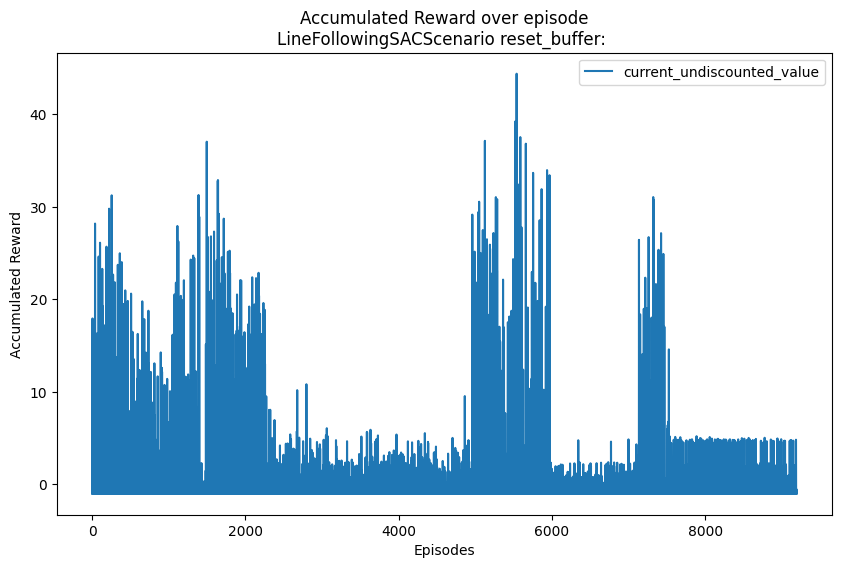

In [7]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 6))
group_df = df.groupby(["iteration_id"]).last()

group_df.reset_index().plot(x="iteration_id", y="current_undiscounted_value", ax=ax)
ax.set_title(f"Accumulated Reward over episode\n{exp_name}")
ax.set_xlabel("Episodes")
ax.set_ylabel("Accumulated Reward")